# PySDKit Demo

A quick tour of [PySDKit](https://github.com/wwhenxuan/PySDKit): project goals first, then the three README examples (EMD / VMD / MVMD), a CEEMDAN noise-robustness stress test, and finally 2D image decomposition with VMD2D.

## 1. Mission and goals

**Signal decomposition** splits a non-stationary, nonlinear observation into simpler intrinsic modes (IMFs), then analyzes each mode in time and frequency. Compared with Fourier or wavelet analysis alone, it is often a better fit for real multicomponent vibration, biomedical, and industrial monitoring records.

Signal-processing research has long been MATLAB-centric, while machine learning lives in Python. As a result, EMD, VMD, and related methods lacked a unified, easy-to-use Python stack—unlike [PyWavelets](https://pywavelets.readthedocs.io/) for wavelets.

**PySDKit aims to:**

1. Unify univariate / multivariate signals and 2D images under a **scikit-learn-style API** (`fit_transform`);
2. Make signal decomposition a practical **feature-engineering** building block for ML and deep learning;
3. Cover mainstream families (EMD, VMD, EWT, ALIF, OSD, …) with matching visualization tools.

Typical workflow: import a method → create an instance → call `fit_transform` → inspect results with `plot_IMFs`.

## 2. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import EMD, VMD, MVMD, CEEMDAN, EEMD, VMD2D
from pysdkit.data import test_vmd, test_grayscale, test_univariate_image
from pysdkit.plot import plot_IMFs

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("PySDKit demo ready")

PySDKit demo ready


## 3. README example 1 — Empirical Mode Decomposition (EMD)

A sum of three cosines (5 / 25 / 80 Hz). EMD sifts recursively by scale and remains the classic baseline for signal decomposition.

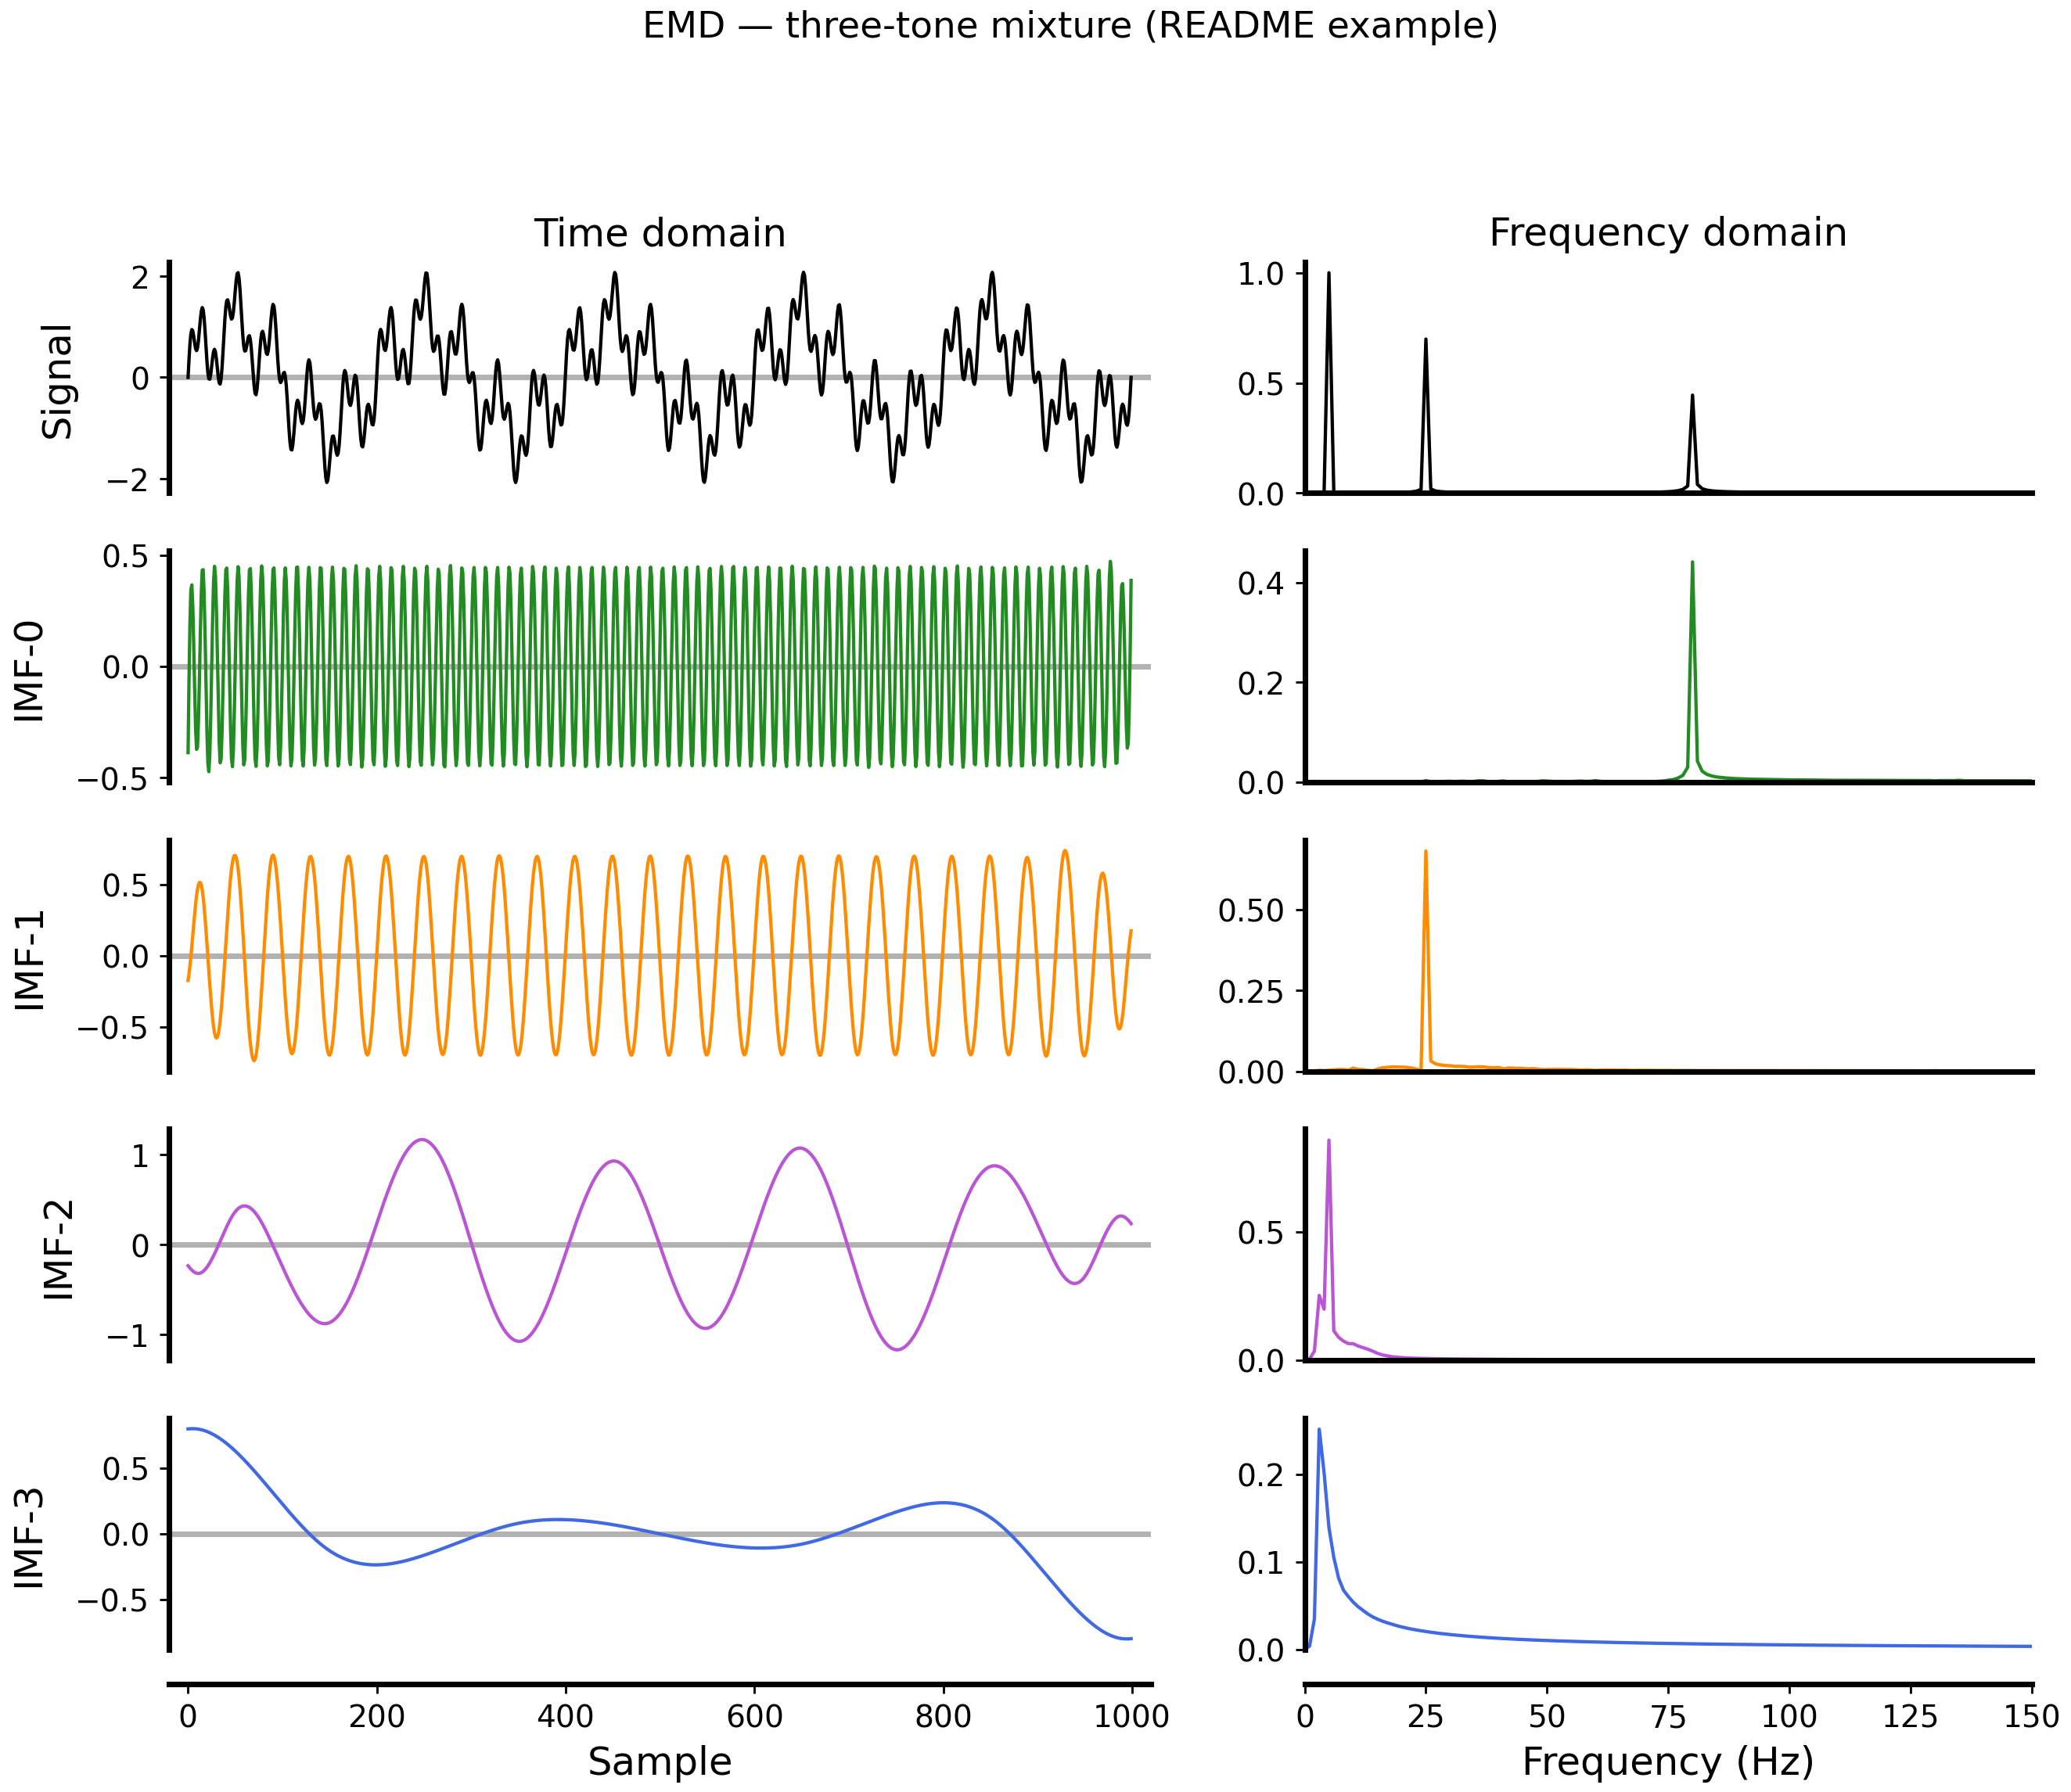

In [2]:
t = np.linspace(0, 1, 1000)
signal = (
    np.sin(2 * np.pi * 5 * t)
    + 0.7 * np.sin(2 * np.pi * 25 * t)
    + 0.45 * np.sin(2 * np.pi * 80 * t)
)

emd = EMD()
IMFs = emd.fit_transform(signal, max_imfs=3)
plot_IMFs(signal, IMFs, view="2d_freq", fs=1000, freq_max=150)
plt.suptitle("EMD — three-tone mixture (README example)", y=1.02)
plt.tight_layout()
plt.show()

## 4. README example 2 — Variational Mode Decomposition (VMD)

For richer multicomponent records, switch to non-recursive VMD: several band-limited modes and their center frequencies are estimated jointly in the Fourier domain. Data come from the packaged helper `test_vmd()`.

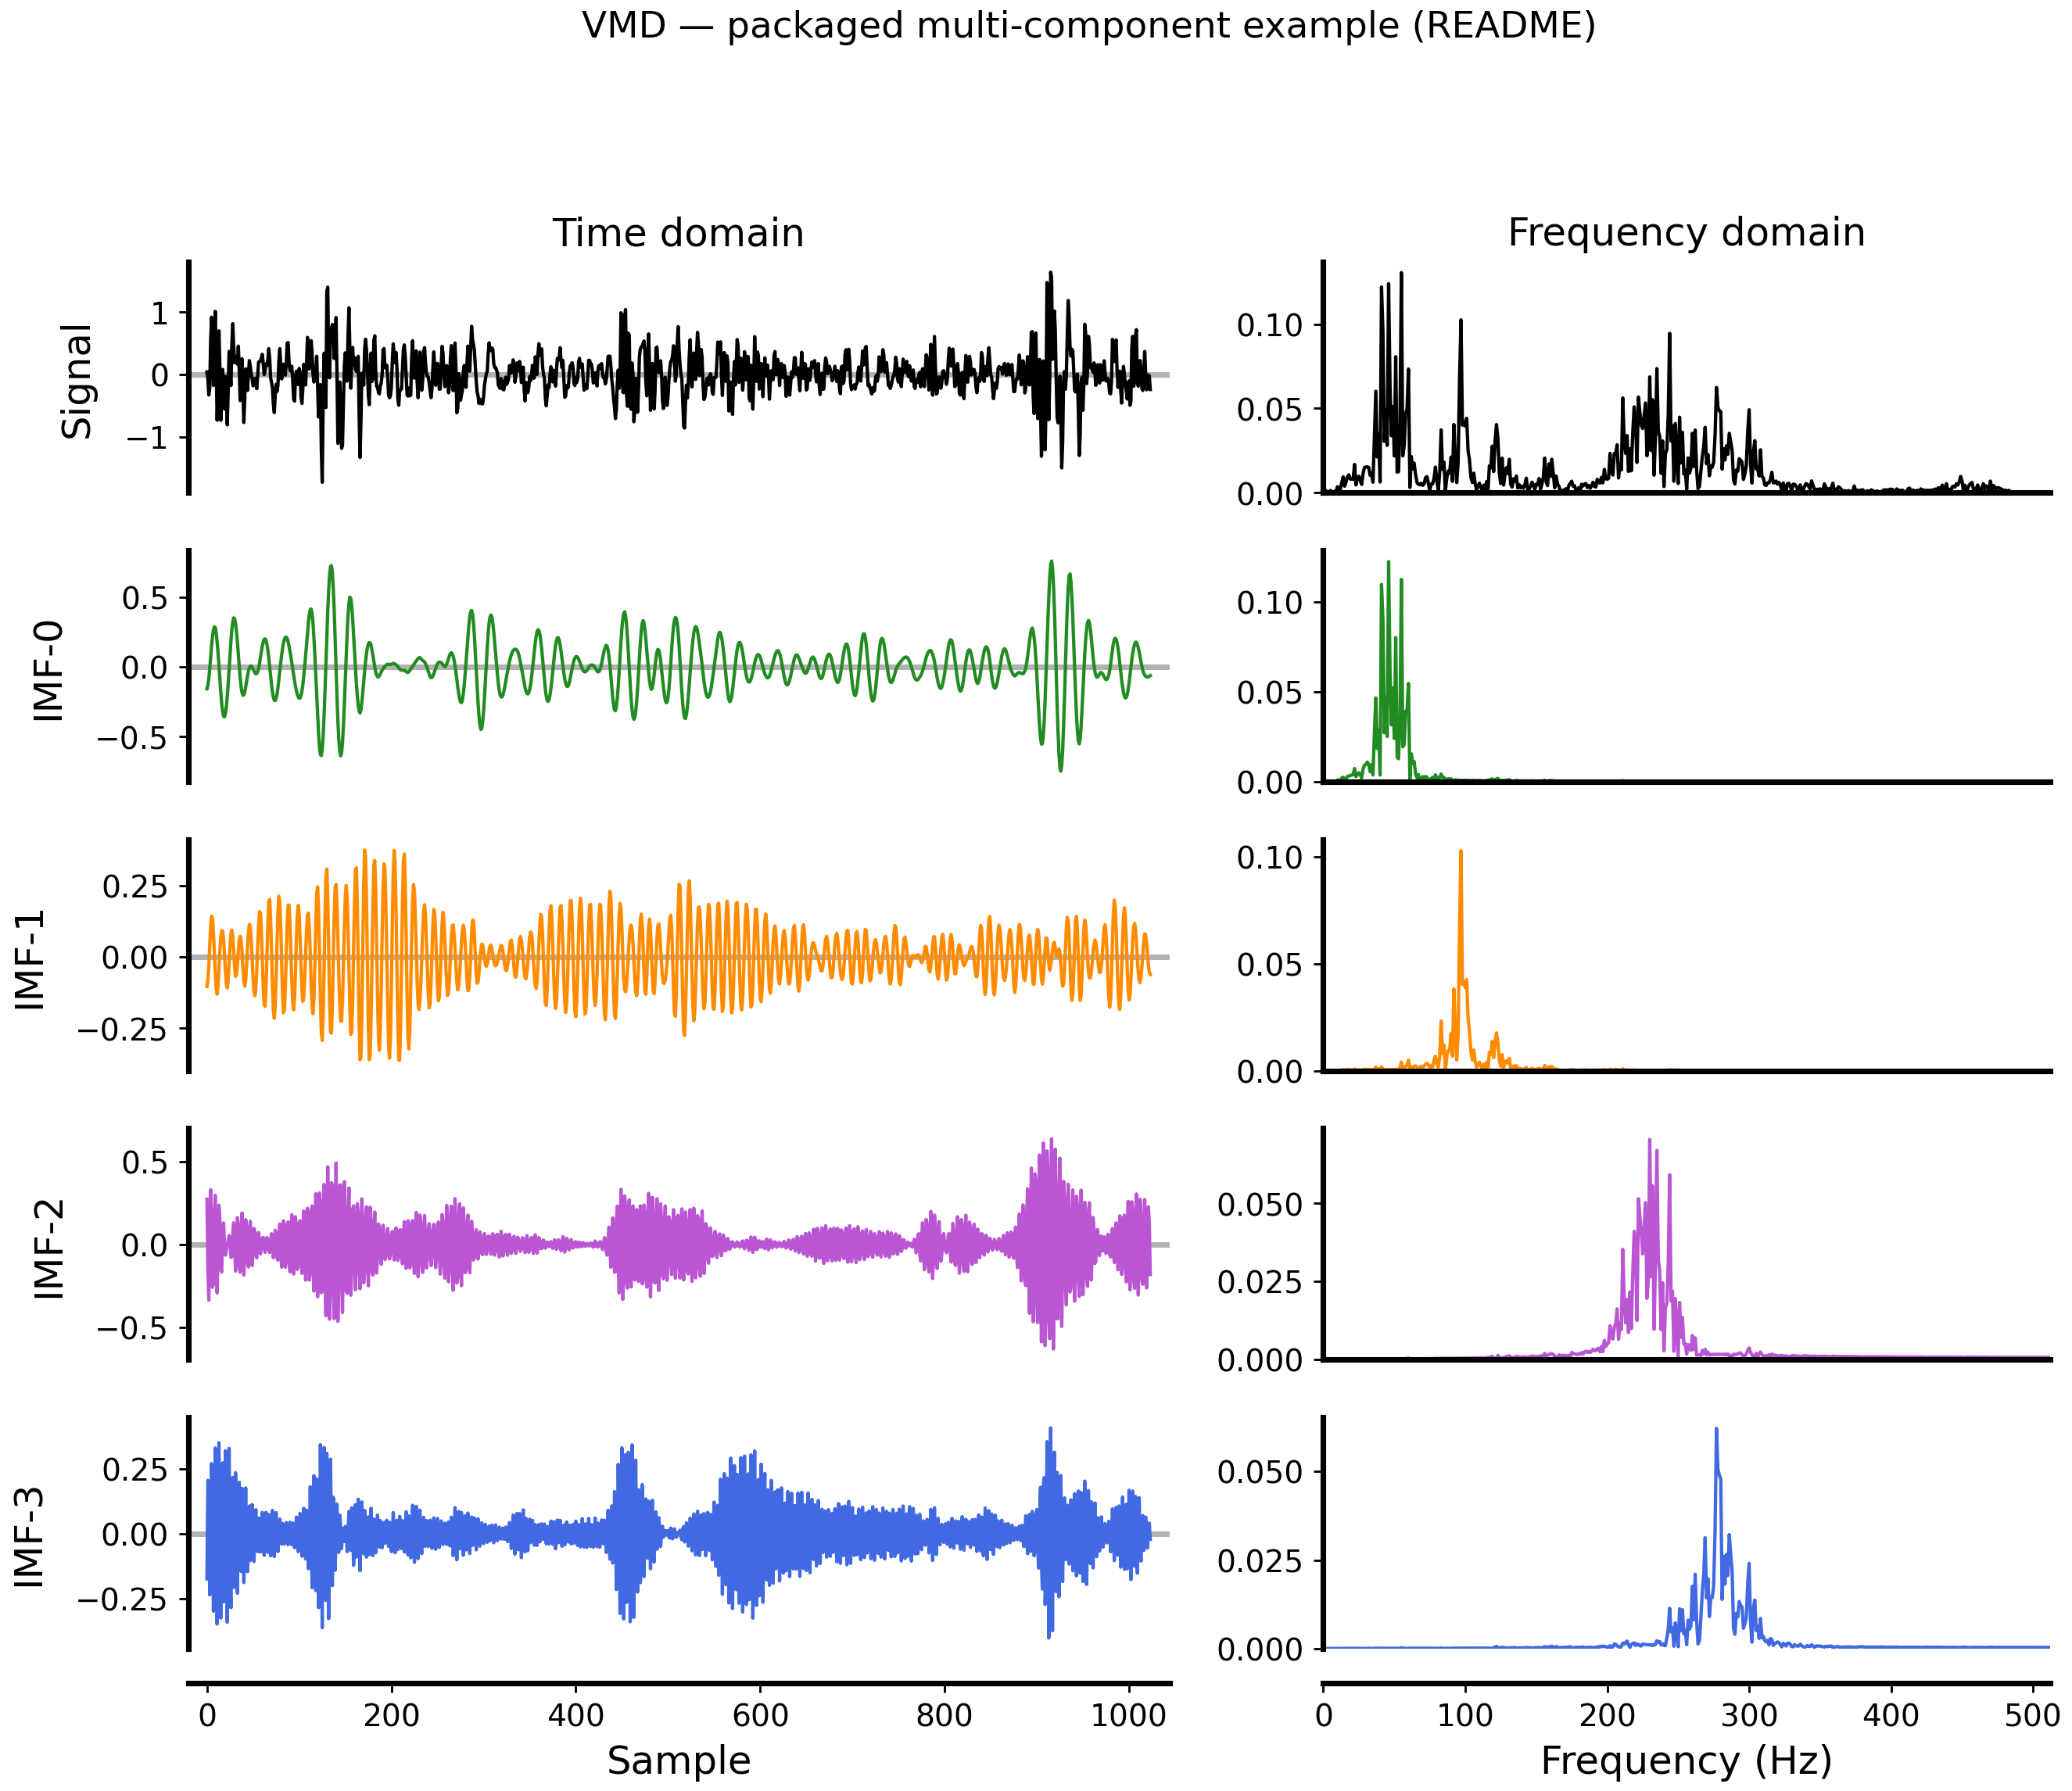

In [3]:
t_v, signal_v, fs_v = test_vmd()

vmd = VMD(alpha=2000, K=4, tau=0.0, tol=1e-7)
IMFs_v = vmd.fit_transform(signal_v)
plot_IMFs(signal_v, IMFs_v, view="2d_freq", fs=fs_v, freq_max=fs_v / 2)
plt.suptitle("VMD — packaged multi-component example (README)", y=1.02)
plt.tight_layout()
plt.show()

## 5. README example 3 — Multivariate VMD (MVMD)

Three channels share a 36 Hz oscillation and each also carries a distinct tone. MVMD keeps modes **aligned across channels** (the same index $k$ maps to the same physical oscillation).

MVMD output shape (K, T, C): (4, 1000, 3)


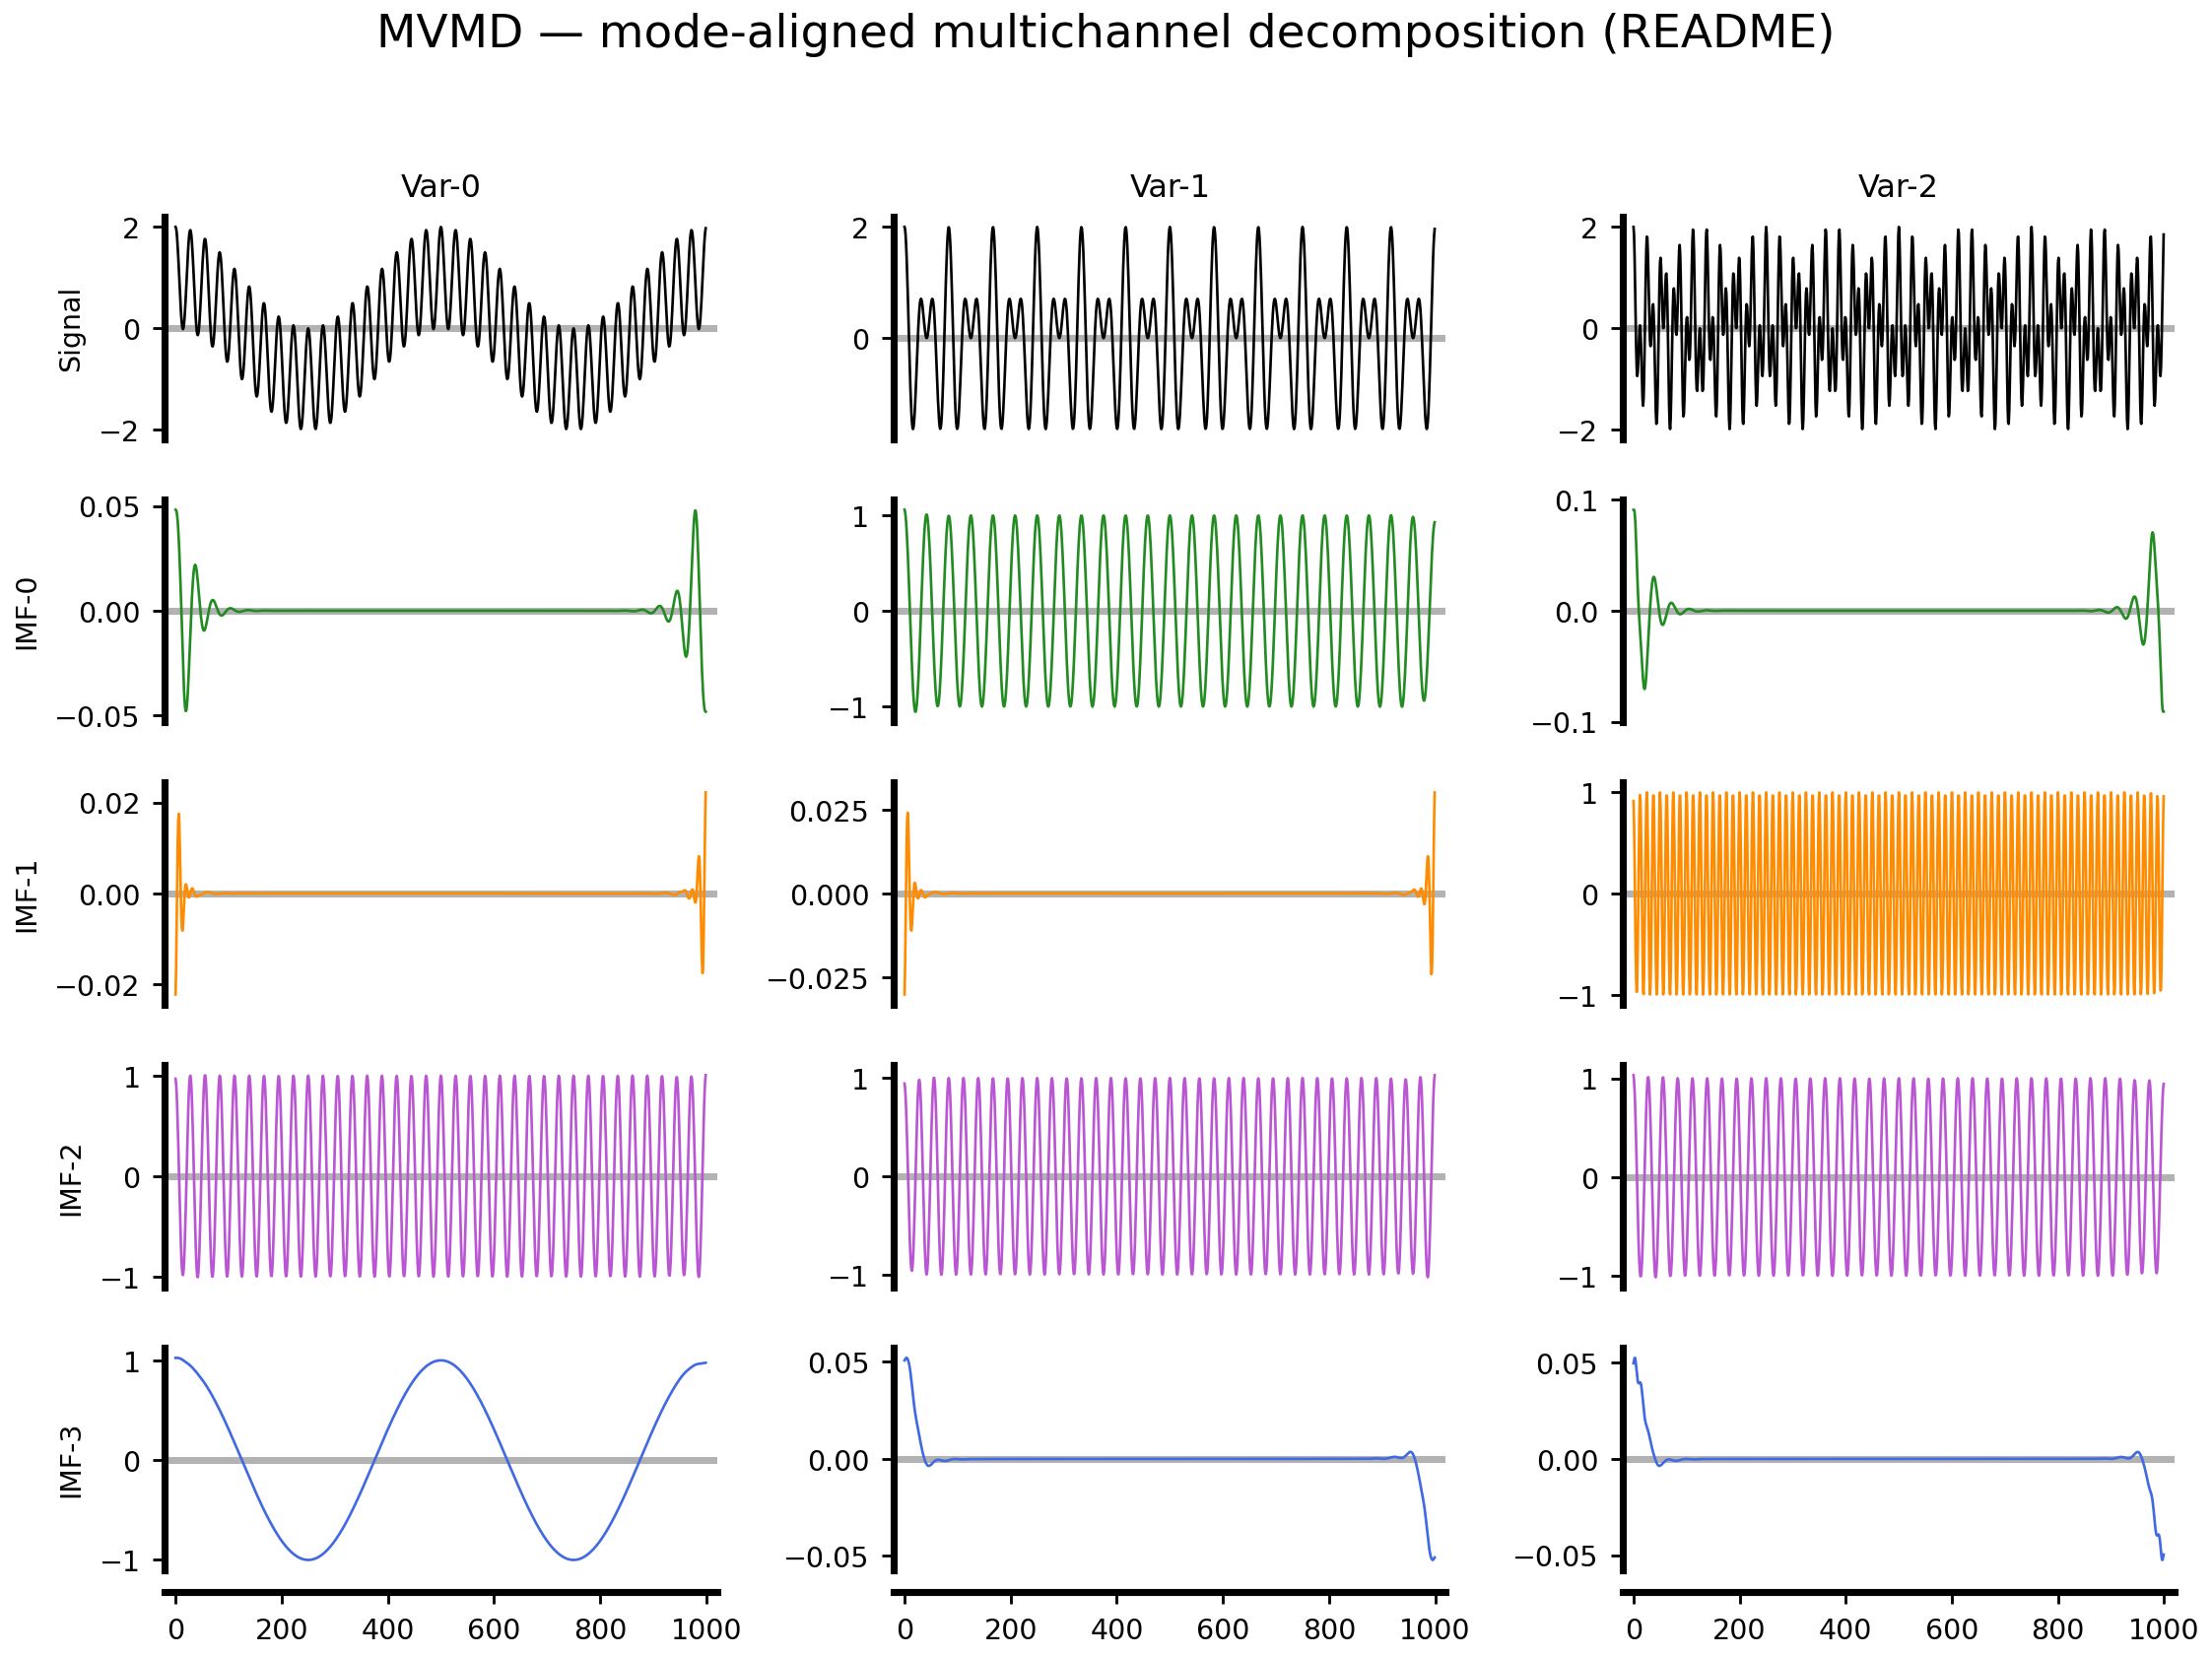

In [4]:
t_m = np.arange(0, 1, 0.001)
# ch1: 2+36 Hz, ch2: 24+36 Hz, ch3: 80+36 Hz (36 Hz shared)
signal_m = np.vstack(
    [
        np.cos(2 * np.pi * 2 * t_m) + np.cos(2 * np.pi * 36 * t_m),
        np.cos(2 * np.pi * 24 * t_m) + np.cos(2 * np.pi * 36 * t_m),
        np.cos(2 * np.pi * 80 * t_m) + np.cos(2 * np.pi * 36 * t_m),
    ]
)

mvmd = MVMD(alpha=2000, K=4, tau=0.0, init="uniform")
IMFs_m = mvmd.fit_transform(signal_m)  # (K, T, C)
print("MVMD output shape (K, T, C):", IMFs_m.shape)

plot_IMFs(signal_m, IMFs_m)
plt.suptitle("MVMD — mode-aligned multichannel decomposition (README)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Special case — CEEMDAN noise robustness

Classic EMD is prone to **mode mixing** under noise. EEMD / CEEMDAN mitigate this with noise-assisted ensembles; CEEMDAN further enforces a **complete** decomposition

$$
x = \sum_k \widetilde{\mathrm{IMF}}_k + R,
$$

so reconstruction error is typically near machine precision. The two stress tests below follow `examples/emd_variants/ceemdan.ipynb`:

1. complete reconstruction of a noisy two-tone mixture;
2. CEEMDAN vs EEMD on a Dirac impulse (Torres *et al.*, Fig. 1 style).

CEEMDAN modes=5, max |x - sum IMFs| = 4.441e-16


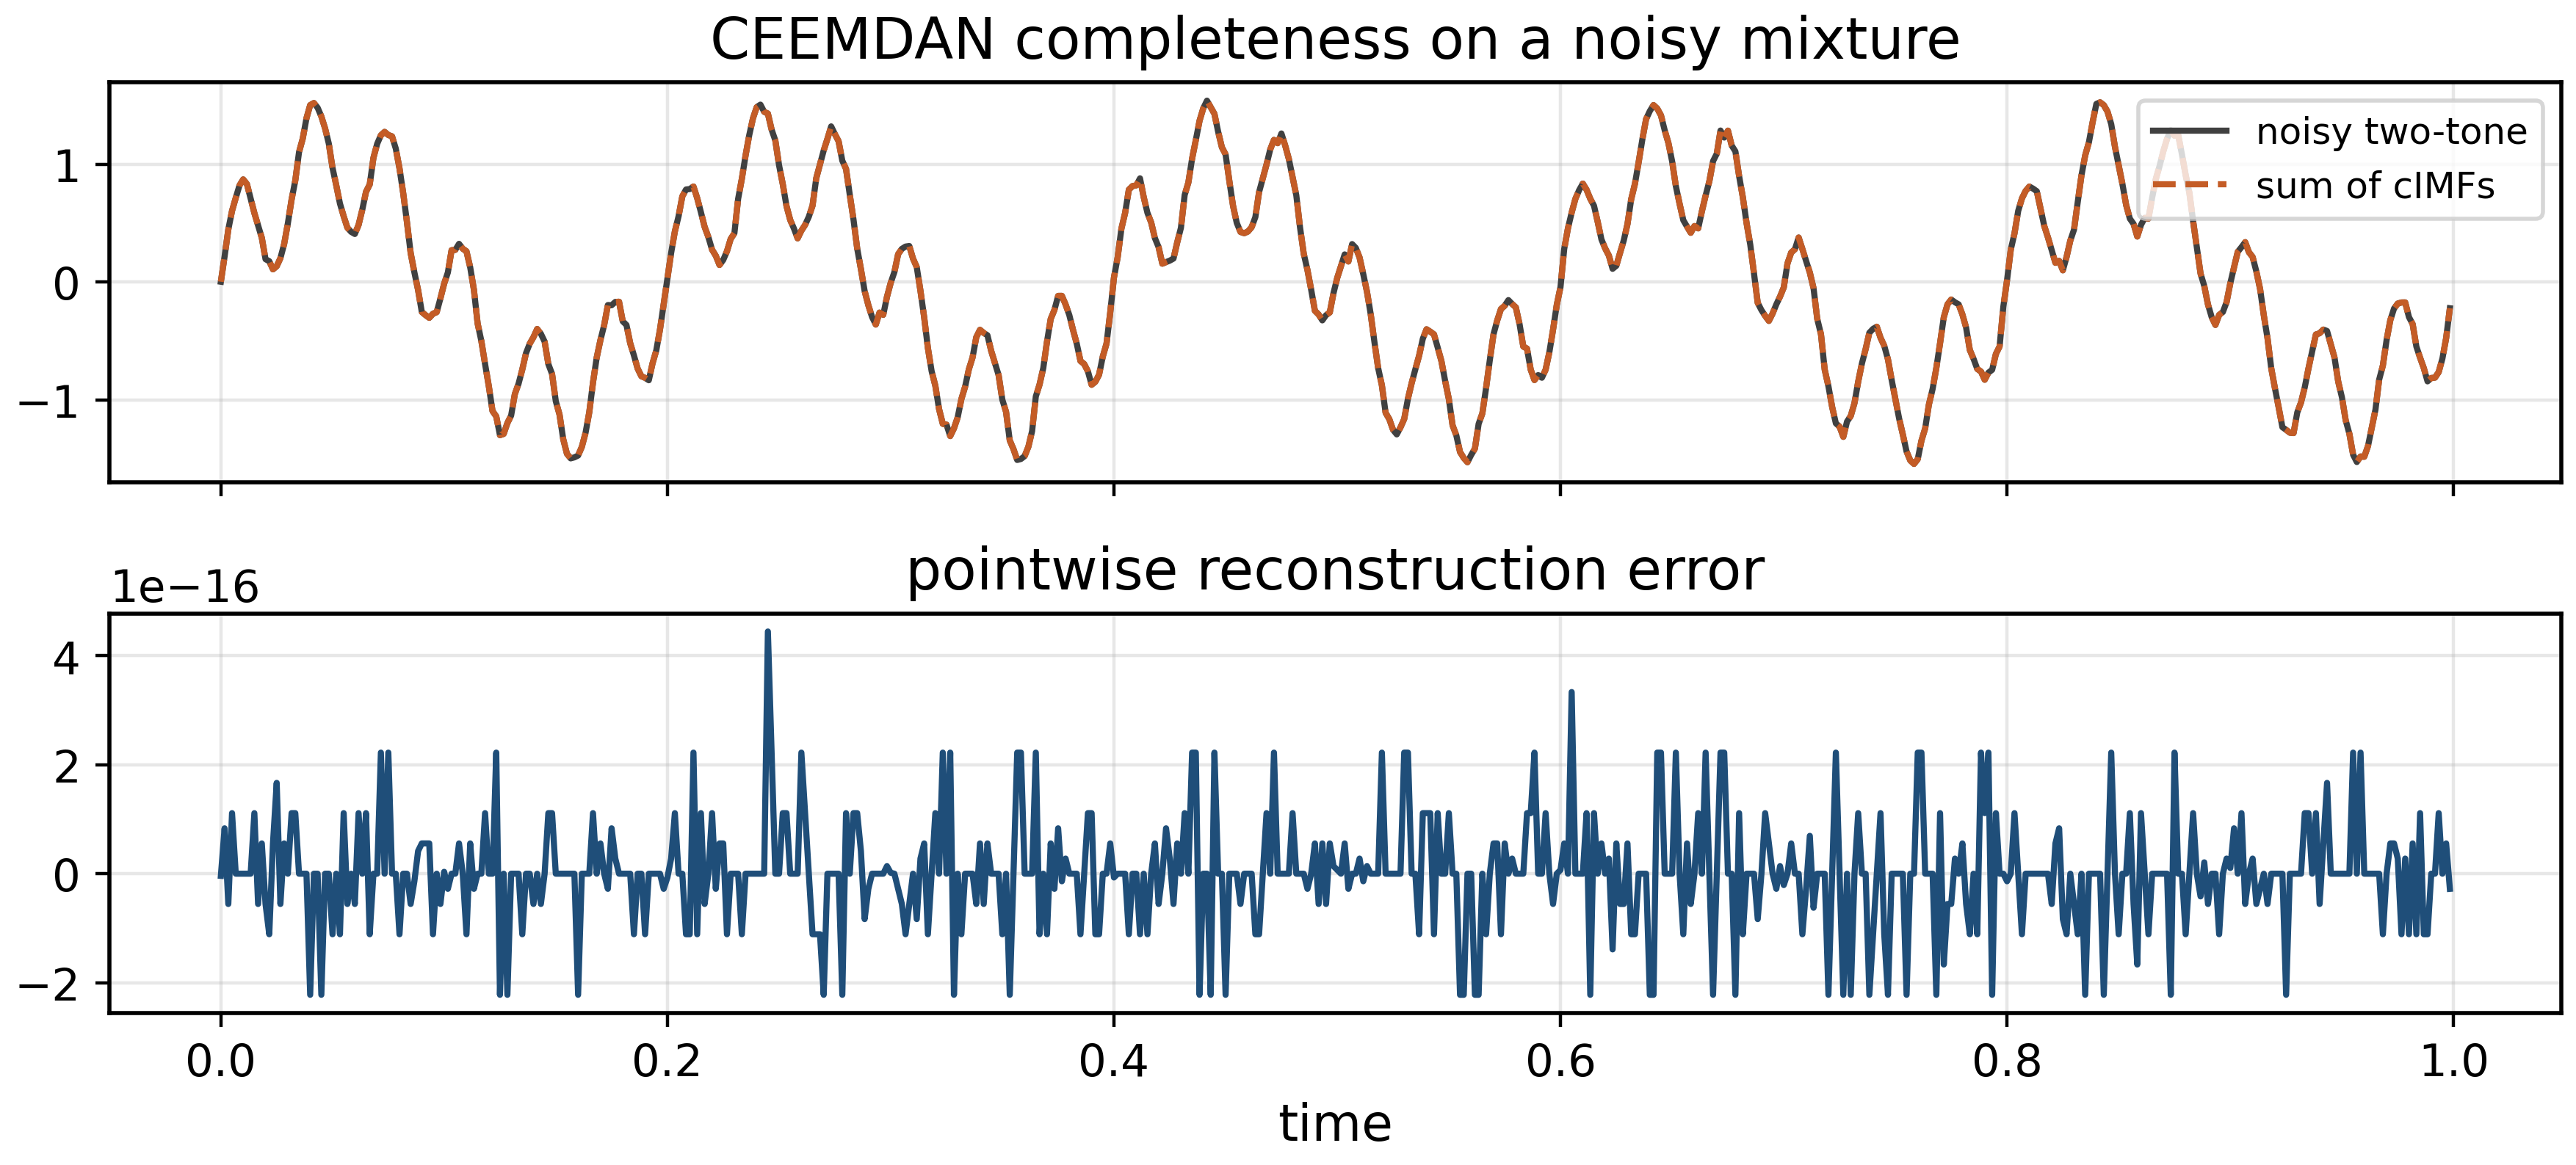

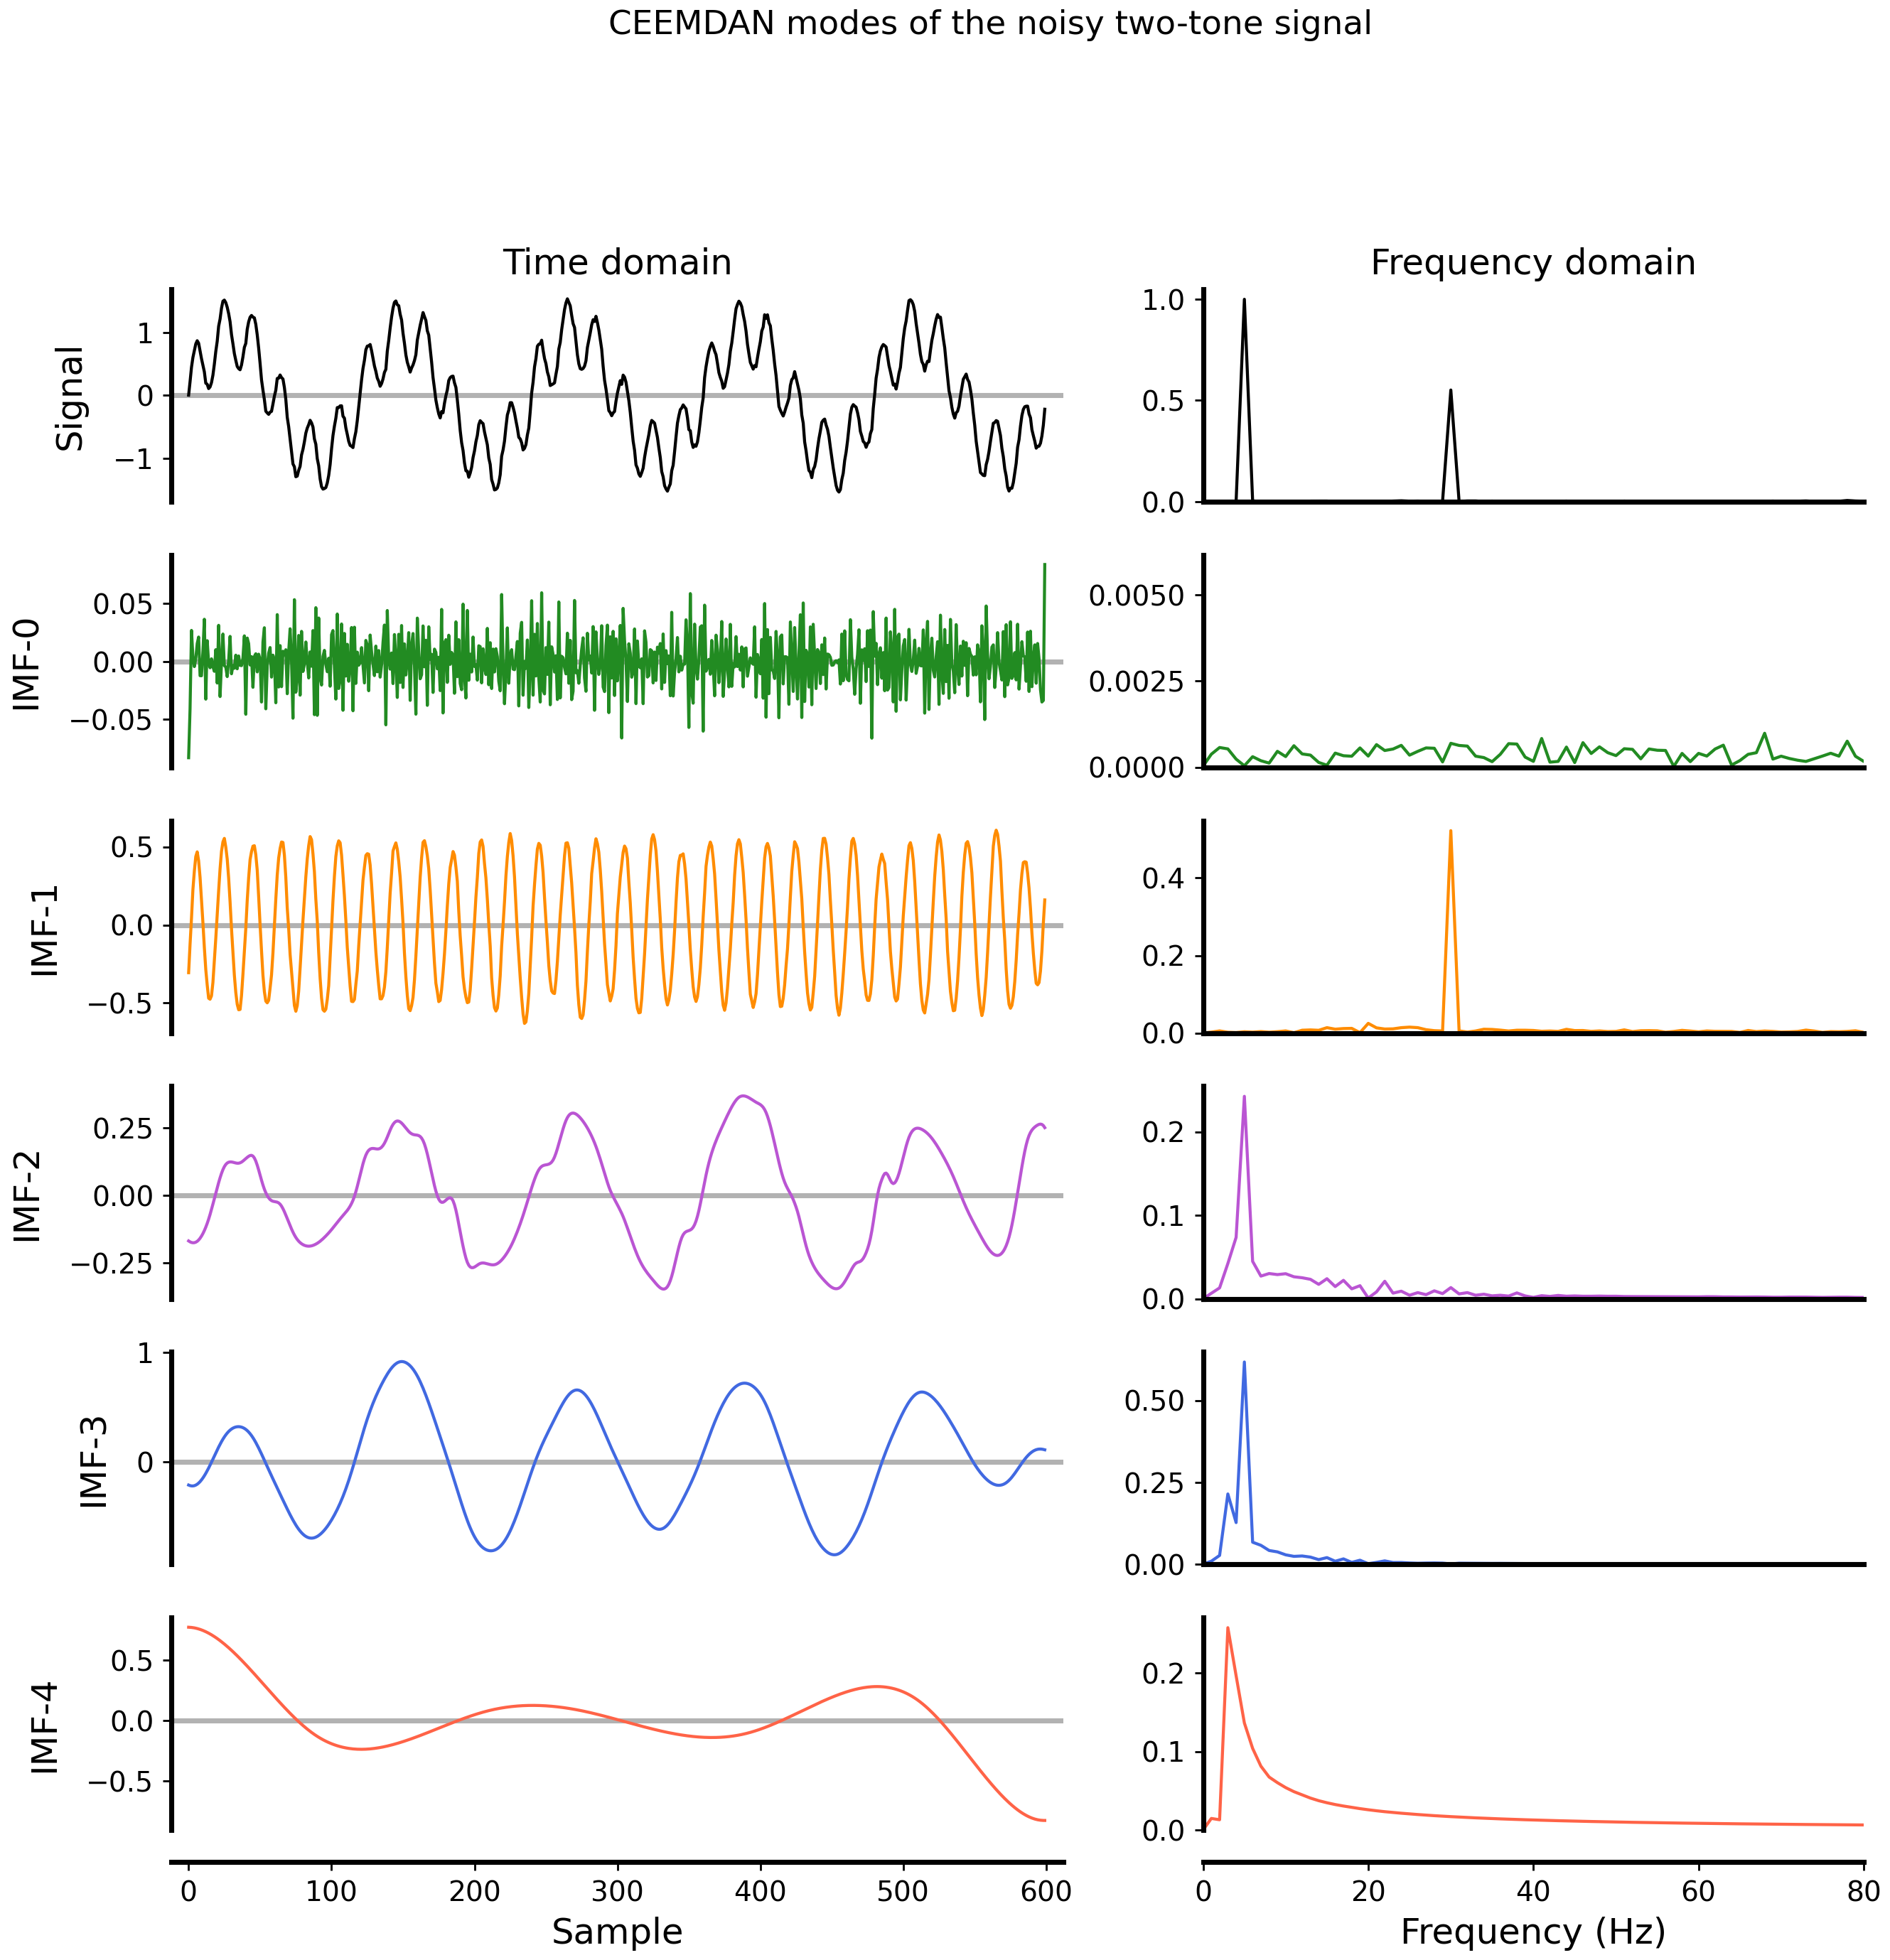

In [5]:
rng = np.random.default_rng(0)
n = 600
t_n = np.linspace(0.0, 1.0, n, endpoint=False)
tone = np.sin(2 * np.pi * 5 * t_n) + 0.55 * np.sin(2 * np.pi * 30 * t_n)
tone = tone + 0.03 * rng.standard_normal(n)

ceemdan = CEEMDAN(
    trials=30,
    epsilon=0.05,
    noise_scale=1.0,
    max_imfs=4,
    random_seed=0,
)
cimfs = ceemdan.fit_transform(tone)
recon = cimfs.sum(axis=0)
err = float(np.max(np.abs(tone - recon)))
print(f"CEEMDAN modes={cimfs.shape[0]}, max |x - sum IMFs| = {err:.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
axes[0].plot(t_n, tone, color="0.25", label="noisy two-tone")
axes[0].plot(t_n, recon, "--", color="#c45c26", label="sum of cIMFs")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_title("CEEMDAN completeness on a noisy mixture")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_n, tone - recon, color="#1f4e79")
axes[1].set_title("pointwise reconstruction error")
axes[1].set_xlabel("time")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_IMFs(tone, cimfs, view="2d_freq", fs=float(n), freq_max=80)
plt.suptitle("CEEMDAN modes of the noisy two-tone signal", y=1.02)
plt.tight_layout()
plt.show()

CEEMDAN: 7 modes | recon err 2.220446049250313e-16
EEMD: 8 modes | mean-only err 0.010390273687127135 | with residue 0.0


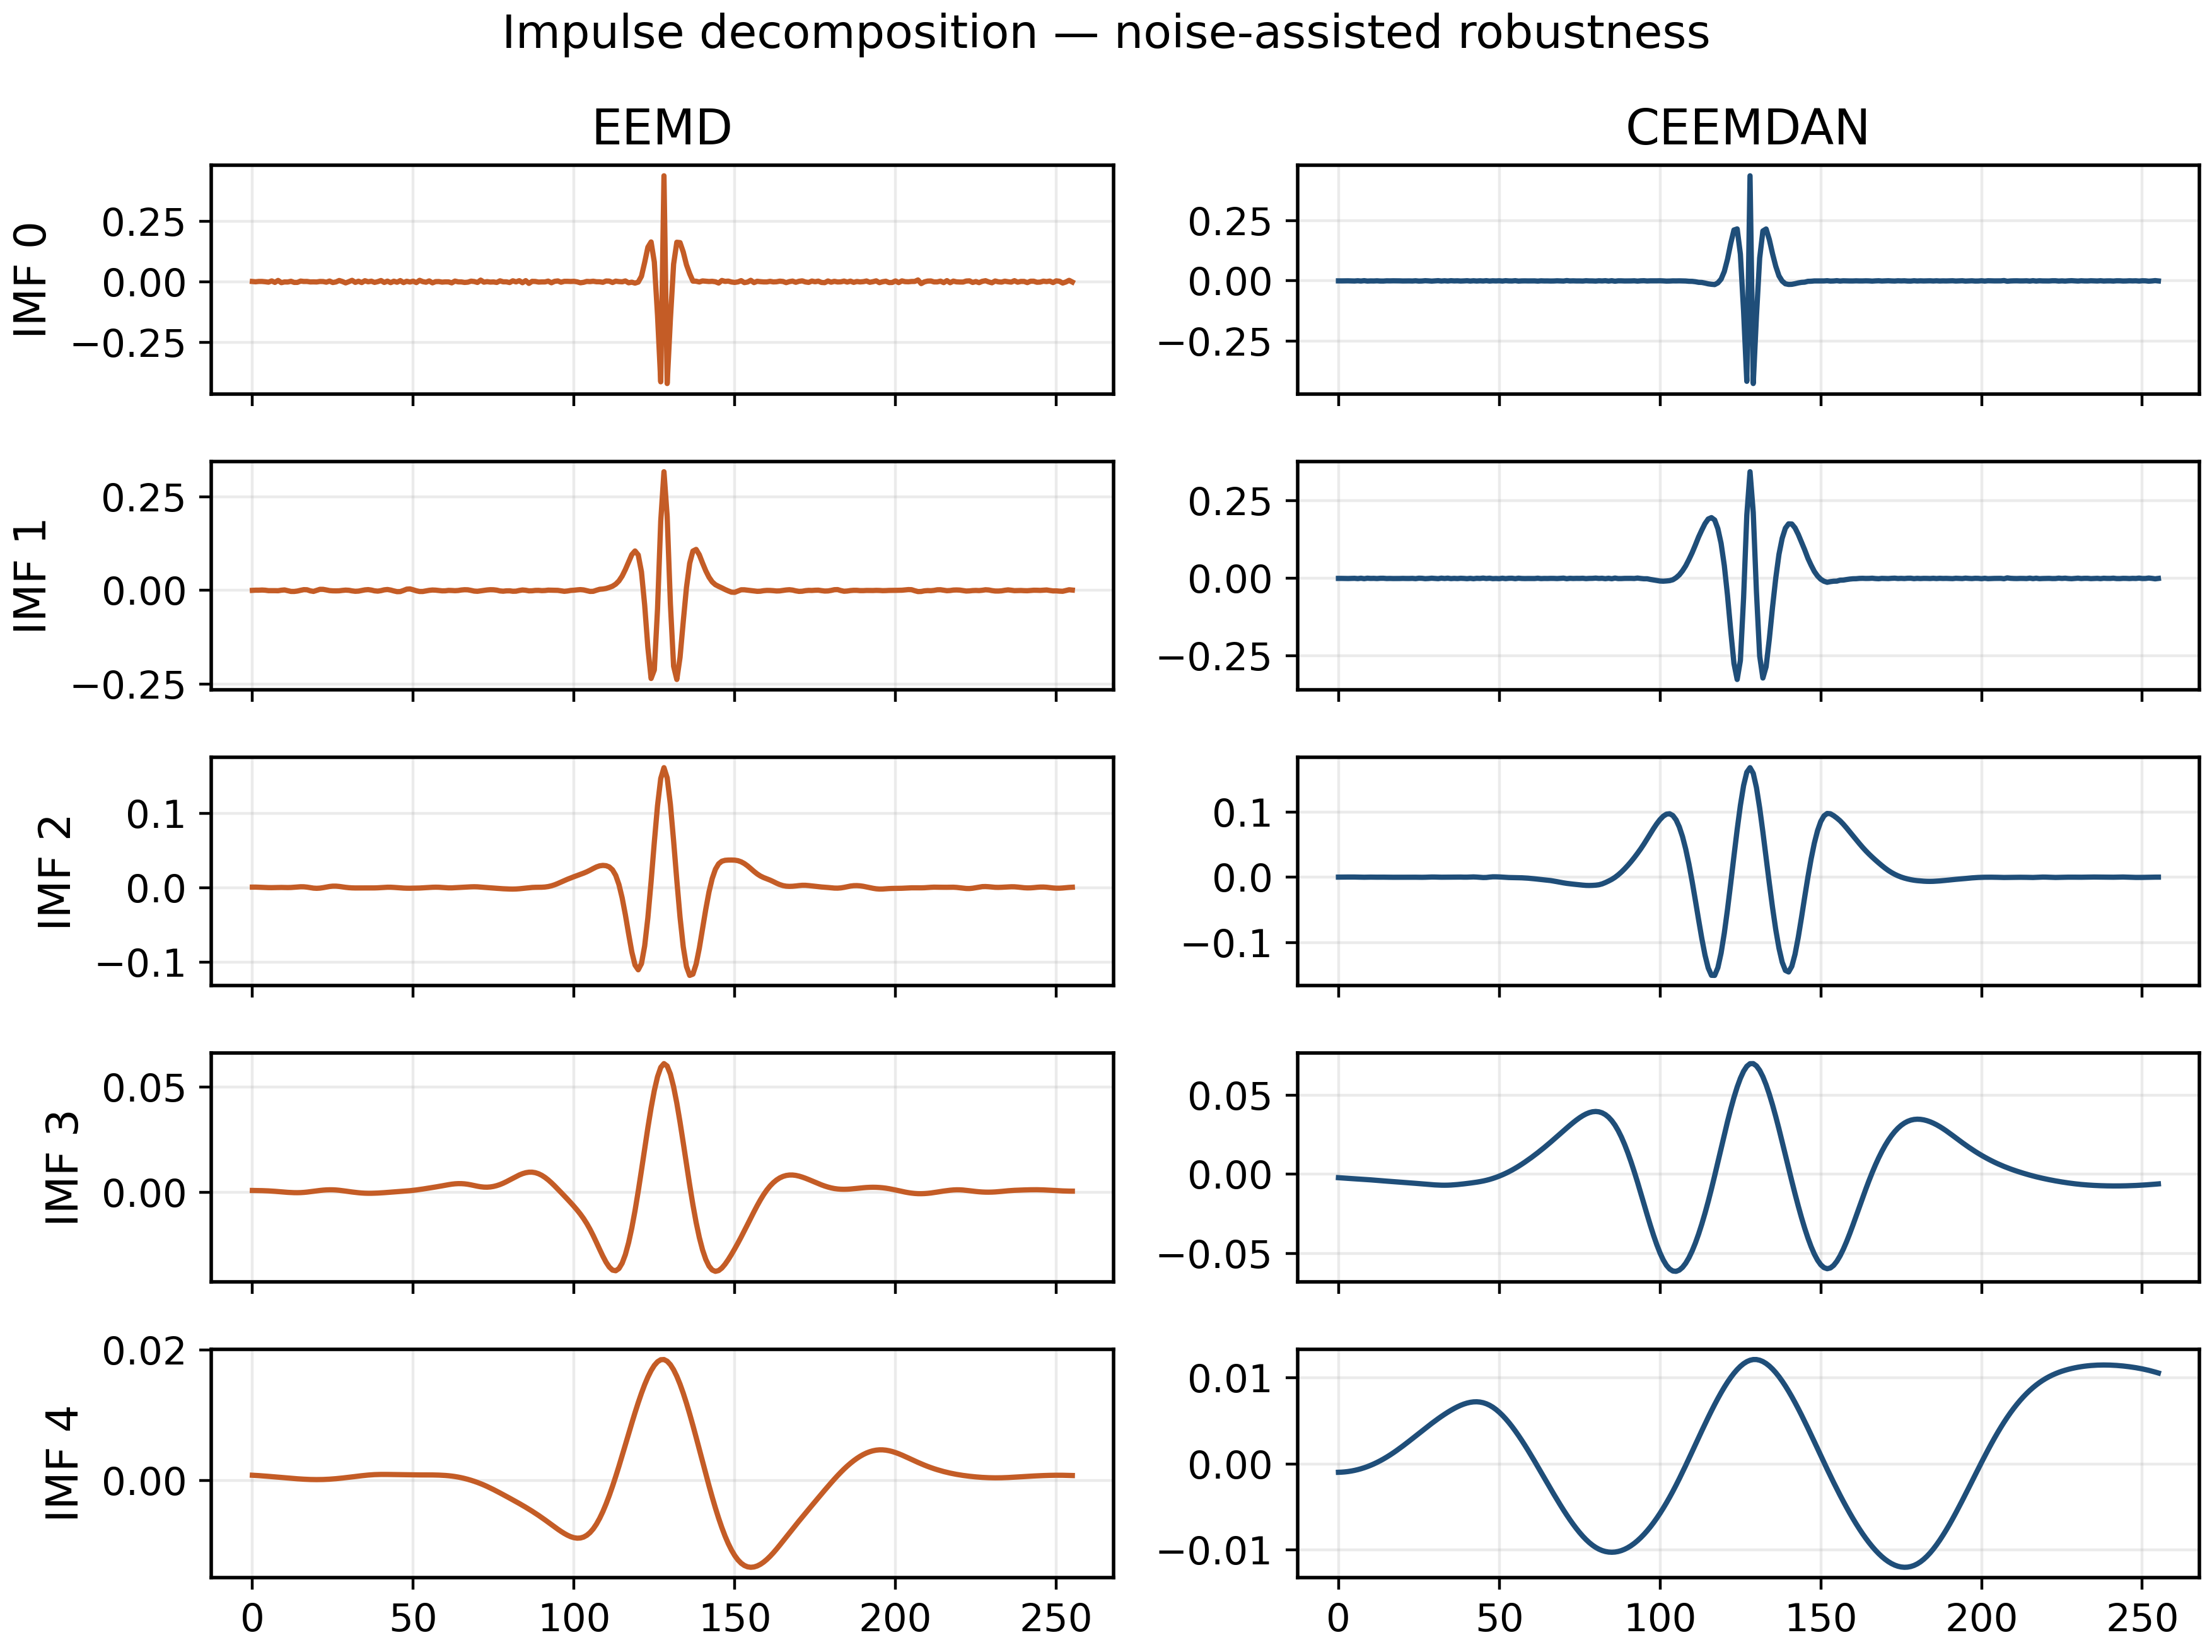

In [6]:
# Dirac impulse stress test — CEEMDAN vs EEMD
impulse = np.zeros(256)
impulse[128] = 1.0

imp_ceemdan = CEEMDAN(
    trials=40,
    epsilon=0.05,
    noise_scale=0.02,
    max_imfs=8,
    random_seed=1,
)
cimfs_i = imp_ceemdan.fit_transform(impulse)

imp_eemd = EEMD(trials=40, noise_width=0.02, max_imfs=8, random_seed=1)
eimfs_i = imp_eemd.fit_transform(impulse)
_, e_res = imp_eemd.get_imfs_and_residue()

print(
    "CEEMDAN:",
    cimfs_i.shape[0],
    "modes | recon err",
    float(np.max(np.abs(impulse - cimfs_i.sum(0)))),
)
print(
    "EEMD:",
    eimfs_i.shape[0],
    "modes | mean-only err",
    float(np.max(np.abs(impulse - eimfs_i.sum(0)))),
    "| with residue",
    float(np.max(np.abs(impulse - (eimfs_i.sum(0) + e_res)))),
)

Kshow = min(5, cimfs_i.shape[0], eimfs_i.shape[0])
fig, axes = plt.subplots(Kshow, 2, figsize=(9, 1.35 * Kshow), sharex=True)
for k in range(Kshow):
    axes[k, 0].plot(eimfs_i[k], color="#c45c26")
    axes[k, 1].plot(cimfs_i[k], color="#1f4e79")
    axes[k, 0].set_ylabel(f"IMF {k}")
    if k == 0:
        axes[k, 0].set_title("EEMD")
        axes[k, 1].set_title("CEEMDAN")
    for ax in axes[k]:
        ax.grid(True, alpha=0.25)
plt.suptitle("Impulse decomposition — noise-assisted robustness")
plt.tight_layout()
plt.show()

## 7. Images — Two-Dimensional VMD (VMD2D)

Dragomiretskiy & Zosso extend VMD to 2D: each mode is compact around an unknown center frequency $\boldsymbol{\omega}_k\in\mathbb{R}^2$, which suits textures and directional oscillations. Below we use `test_grayscale()` (paper-style synthetic texture) and `test_univariate_image` for a quick demo; full experiments live in `examples/image/vmd2d.ipynb`.

grayscale texture shape: (256, 256)
VMD2D modes shape: (256, 256, 5)
relative recon error: 7.0384e-01


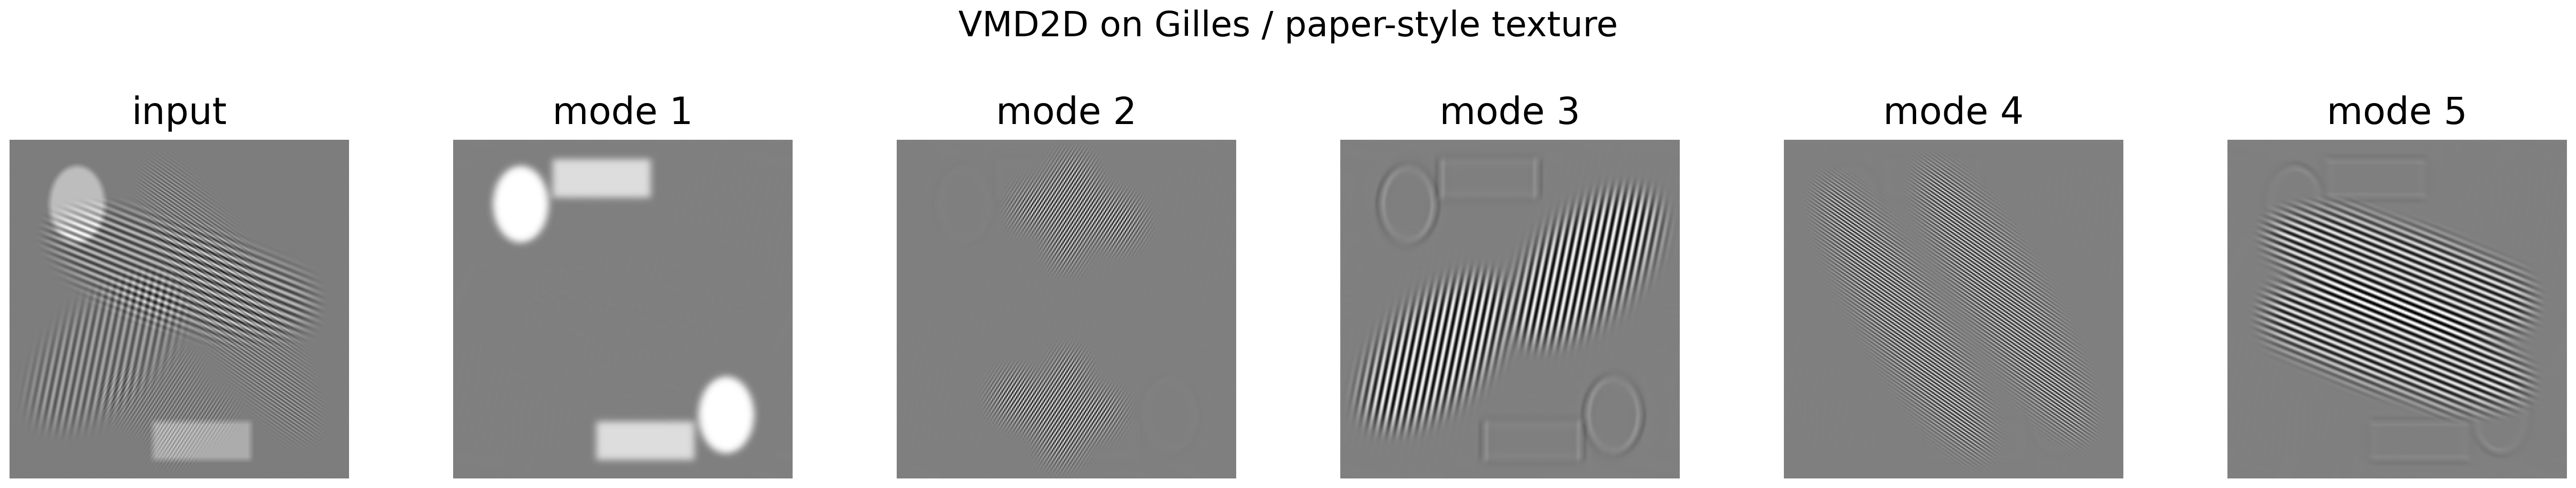

In [7]:
def show_image_modes(img, modes, title=""):
    """modes: (H, W, K)"""
    K = modes.shape[2]
    fig, axs = plt.subplots(1, K + 1, figsize=(2.35 * (K + 1), 2.5))
    axs[0].imshow(img, cmap="gray")
    axs[0].set_title("input")
    axs[0].axis("off")
    for k in range(K):
        lim = np.percentile(np.abs(modes[:, :, k]), 99) + 1e-12
        axs[k + 1].imshow(modes[:, :, k], cmap="gray", vmin=-lim, vmax=lim)
        axs[k + 1].set_title(f"mode {k + 1}")
        axs[k + 1].axis("off")
    if title:
        fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


img = test_grayscale()
print("grayscale texture shape:", img.shape)

vmd2d = VMD2D(
    K=5,
    alpha=1000,
    tau=0.25,
    DC=True,
    init="random",
    tol=1e-6,
    max_iter=200,  # shorter than paper (~520) for a quick demo
)
modes_2d = vmd2d.fit_transform(img)  # (H, W, K)
print("VMD2D modes shape:", modes_2d.shape)
recon_err = np.linalg.norm(img - modes_2d.sum(axis=2)) / (np.linalg.norm(img) + 1e-16)
print(f"relative recon error: {recon_err:.4e}")

show_image_modes(img, modes_2d, title="VMD2D on Gilles / paper-style texture")

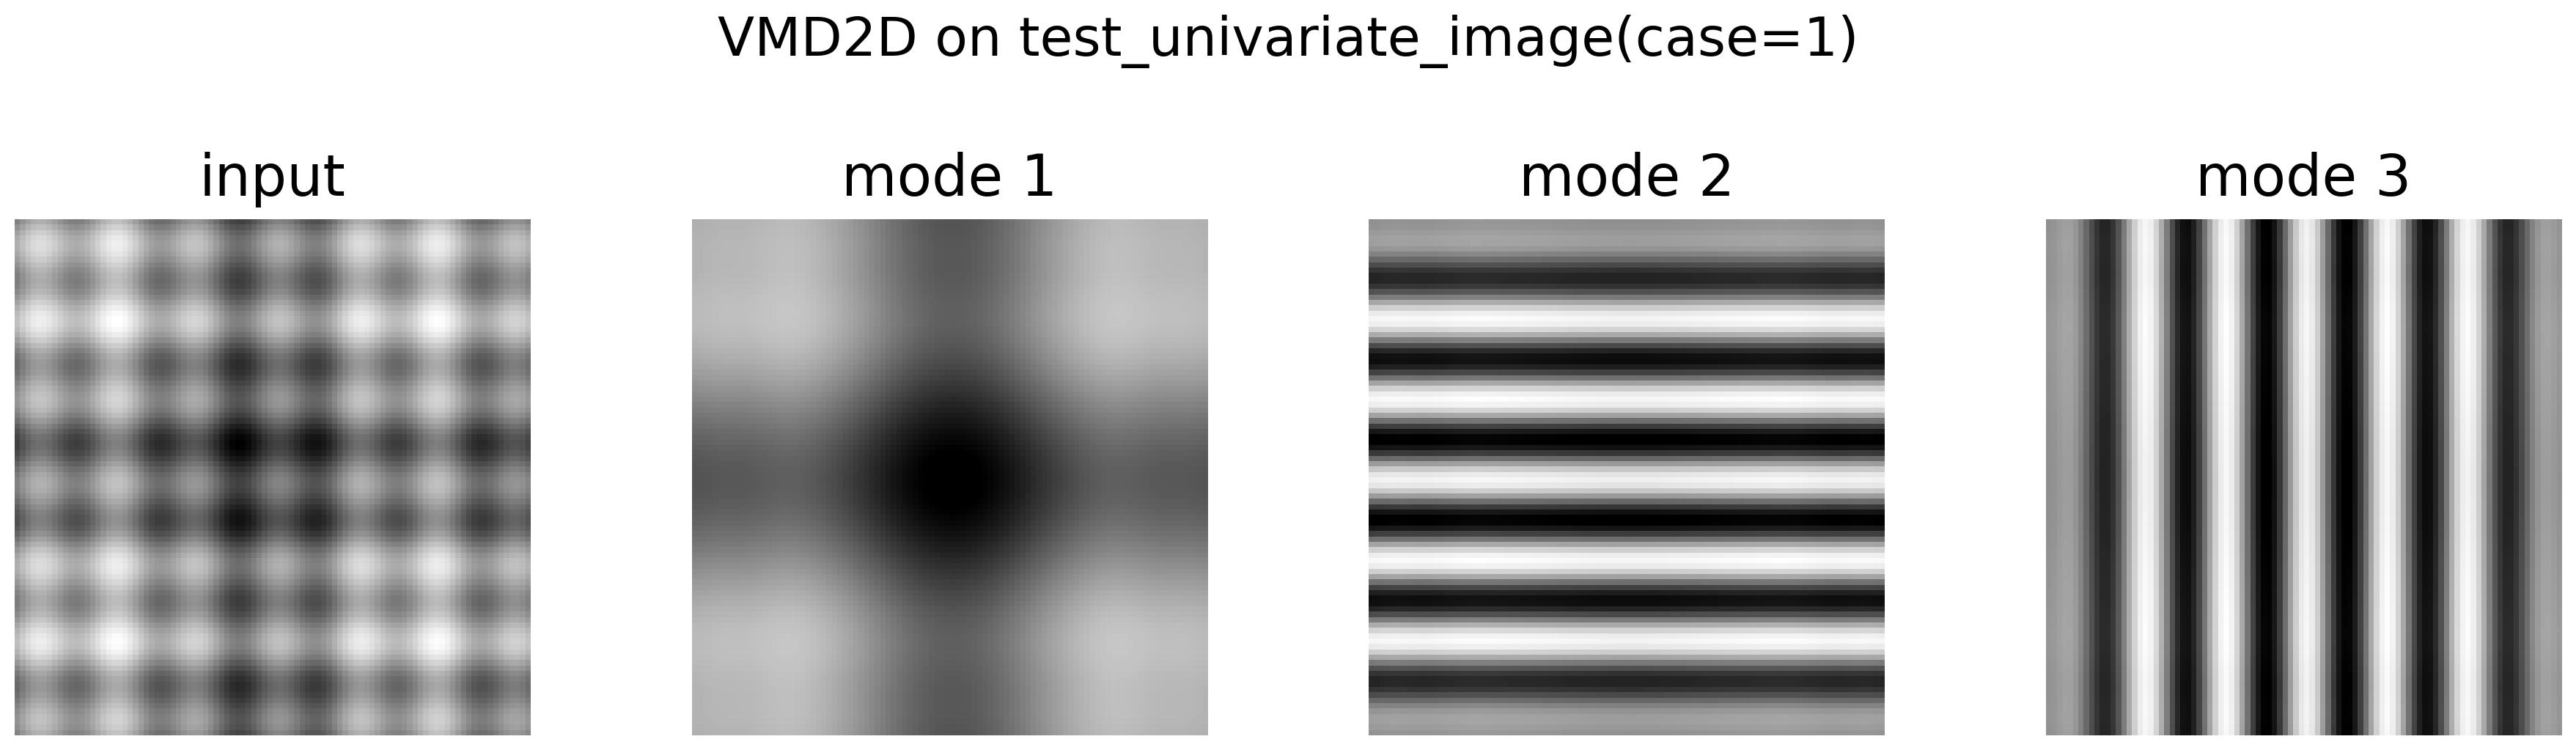

In [8]:
# Controllable meshgrid mixture (fast oscillation + slow + trend)
img1 = test_univariate_image(case=1, low=0, high=10, sampling_rate=96)
vmd_mesh = VMD2D(
    K=3,
    alpha=2000,
    tau=0.0,
    DC=True,
    init="random",
    tol=1e-6,
    max_iter=150,
)
modes1 = vmd_mesh.fit_transform(img1)
show_image_modes(img1, modes1, title="VMD2D on test_univariate_image(case=1)")

## 8. Takeaways

| Demo | Method | Role |
| --- | --- | --- |
| README #1 | `EMD` | Classic recursive sifting; clear scale separation |
| README #2 | `VMD` | Non-recursive band-limited modes; complex mixtures |
| README #3 | `MVMD` | Mode-aligned shared oscillations across channels |
| Noise robustness | `CEEMDAN` | Complete reconstruction + adaptive noise ensemble |
| Images | `VMD2D` | Texture decomposition around 2D center frequencies |

```python
from pysdkit import EMD, VMD, MVMD, CEEMDAN, VMD2D
from pysdkit.plot import plot_IMFs

IMFs = EMD().fit_transform(signal, max_imfs=3)
plot_IMFs(signal, IMFs, view="2d_freq", fs=1000)
```

More topic notebooks are under `examples/` (`emd_variants/`, `image/`, `osd/`, …).